## 1. Instalasi Dependensi

Jalankan cell berikut untuk memastikan semua paket yang diperlukan terinstal.

In [1]:
%pip install -q numpy matplotlib scikit-learn joblib pillow seaborn
print('✓ Instalasi selesai.')

✓ Instalasi selesai.


## 2. Load Dataset MNIST

Dataset MNIST berisi 70.000 citra angka tulisan tangan (60.000 data latih + 10.000 data uji), dengan ukuran 28×28 piksel grayscale (flatten menjadi 784 fitur).

In [2]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# Load MNIST dataset dari OpenML
print('Loading MNIST dataset...')
X_raw, y_raw = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

# Konversi tipe data
X = X_raw.astype(np.float32)
y = y_raw.astype(np.int64)

print('✓ MNIST loaded!')
print('Shape data:', X.shape, y.shape)
print('Kelas digit:', np.unique(y))

Loading MNIST dataset...
✓ MNIST loaded!
Shape data: (70000, 784) (70000,)
Kelas digit: [0 1 2 3 4 5 6 7 8 9]


### 2.1 Visualisasi Contoh Dataset

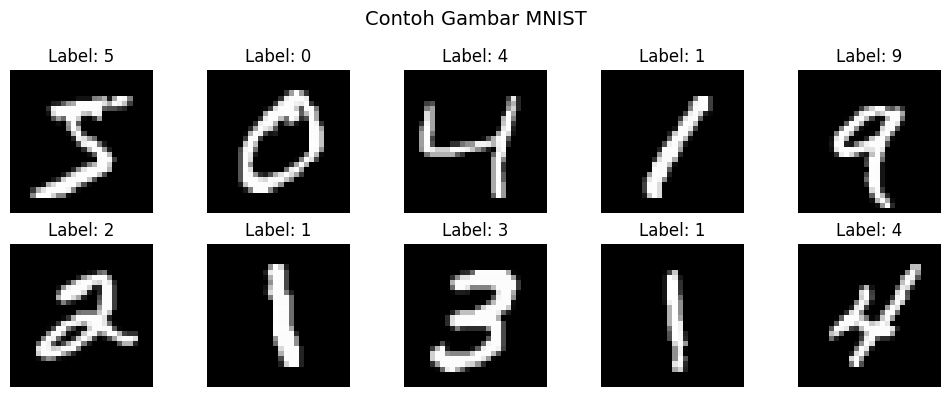

In [3]:
def draw_img(sample_784, label=None, title=None):
    """Fungsi helper untuk menampilkan gambar dari vektor 784 piksel"""
    img = sample_784.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    if title is not None:
        plt.title(title)
    elif label is not None:
        plt.title(f'Label: {label}')
    plt.axis('off')

# Tampilkan 10 contoh gambar dari dataset
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    draw_img(X[i], y[i])
plt.suptitle('Contoh Gambar MNIST', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Pembagian Data (Train/Test Split)

Data dibagi dengan proporsi 80% untuk data latih dan 20% untuk data uji, sesuai dengan metodologi penelitian.

In [4]:
# Split 80% train, 20% test
split_idx = int(0.8 * X.shape[0])
X_train = X[:split_idx]
y_train = y[:split_idx]
X_test = X[split_idx:]
y_test = y[split_idx:]

# Untuk efisiensi komputasi, gunakan subset data
TRAIN_N = 56000  # Menggunakan semua data training (80% dari 70k)
TEST_N = 2000    # Subset data uji untuk evaluasi

X_train_s = X_train[:TRAIN_N]
y_train_s = y_train[:TRAIN_N]
X_test_s = X_test[:TEST_N]
y_test_s = y_test[:TEST_N]

print('Data Train (full):', X_train.shape, '| Data Test (full):', X_test.shape)
print('Data Train (used):', X_train_s.shape, '| Data Test (used):', X_test_s.shape)
print(f'\n✓ Data siap digunakan untuk training KNN')

Data Train (full): (56000, 784) | Data Test (full): (14000, 784)
Data Train (used): (56000, 784) | Data Test (used): (2000, 784)

✓ Data siap digunakan untuk training KNN


## 4. Implementasi Algoritma K-Nearest Neighbor (KNN)

KNN bekerja dengan menghitung jarak Euclidean antara sampel uji dan semua sampel latih, kemudian memilih K tetangga terdekat dan melakukan voting mayoritas untuk menentukan kelas prediksi.

**Formula Jarak Euclidean:**

$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

In [5]:
def knn_predict_one(X_train, y_train, query_point, k=5):
    """
    Prediksi label untuk satu sampel menggunakan KNN manual.

    Parameters:
    - X_train: data training (N x 784)
    - y_train: label training (N,)
    - query_point: sampel yang akan diprediksi (784,)
    - k: jumlah tetangga terdekat

    Returns:
    - predicted_label: label hasil prediksi (int)
    """

    dists = np.sqrt(np.sum((X_train - query_point) ** 2, axis=1))


    k = int(k)
    idx = np.argpartition(dists, k)[:k]

    labels = y_train[idx]


    counts = np.bincount(labels, minlength=10)
    best_count = counts.max()
    candidates = np.flatnonzero(counts == best_count)

    # Jika tidak ada tie, return langsung
    if candidates.size == 1:
        return int(candidates[0])

    # Tie-breaking: pilih kandidat dengan rata-rata jarak terkecil
    best_label = None
    best_mean = None
    for c in candidates:
        mean_d = dists[idx][labels == c].mean()
        if best_mean is None or mean_d < best_mean:
            best_mean = mean_d
            best_label = int(c)

    return int(best_label)

def knn_predict_batch(X_train, y_train, X_query, k=5):
    """Prediksi batch untuk multiple samples"""
    preds = np.empty((X_query.shape[0],), dtype=np.int64)
    for i in range(X_query.shape[0]):
        preds[i] = knn_predict_one(X_train, y_train, X_query[i], k=k)
    return preds

# Set nilai K
K = 5
print(f'✓ Implementasi KNN siap digunakan (K = {K})')

✓ Implementasi KNN siap digunakan (K = 5)


## 5. Evaluasi Model KNN

### 5.1 Contoh Prediksi

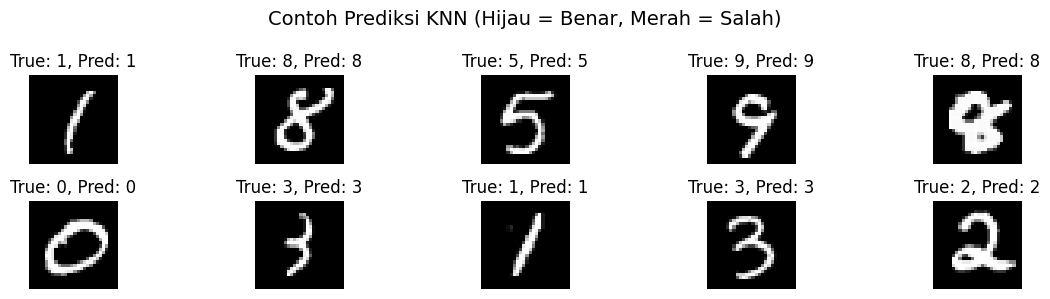

In [6]:
# Contoh prediksi pada 10 sampel pertama dari data uji
SHOW_N = 10

plt.figure(figsize=(12, 3))
for i in range(SHOW_N):
    pred = knn_predict_one(X_train_s, y_train_s, X_test_s[i], k=K)
    plt.subplot(2, 5, i + 1)

    # Tampilkan dengan warna hijau jika benar, merah jika salah
    is_correct = (pred == y_test_s[i])
    color = 'green' if is_correct else 'red'
    draw_img(X_test_s[i], title=f"True: {y_test_s[i]}, Pred: {pred}")
    plt.gca().spines['bottom'].set_color(color)
    plt.gca().spines['top'].set_color(color)
    plt.gca().spines['left'].set_color(color)
    plt.gca().spines['right'].set_color(color)
    plt.gca().spines['bottom'].set_linewidth(3)
    plt.gca().spines['top'].set_linewidth(3)
    plt.gca().spines['left'].set_linewidth(3)
    plt.gca().spines['right'].set_linewidth(3)

plt.suptitle('Contoh Prediksi KNN (Hijau = Benar, Merah = Salah)', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Perhitungan Akurasi

In [7]:
def calculate_accuracy(X_test, y_test, X_train, y_train, k=5):
    """Hitung akurasi model KNN"""
    correct = 0
    for i in range(X_test.shape[0]):
        pred = knn_predict_one(X_train, y_train, X_test[i], k=k)
        if pred == int(y_test[i]):
            correct += 1
    return correct / X_test.shape[0]

# Hitung akurasi pada subset data uji
acc = calculate_accuracy(X_test_s, y_test_s, X_train_s, y_train_s, k=K)
print(f'Akurasi Model (K={K}): {acc*100:.2f}%')

Akurasi Model (K=5): 97.55%


### 5.3 Confusion Matrix dan Classification Report

Melakukan prediksi untuk evaluasi lengkap...


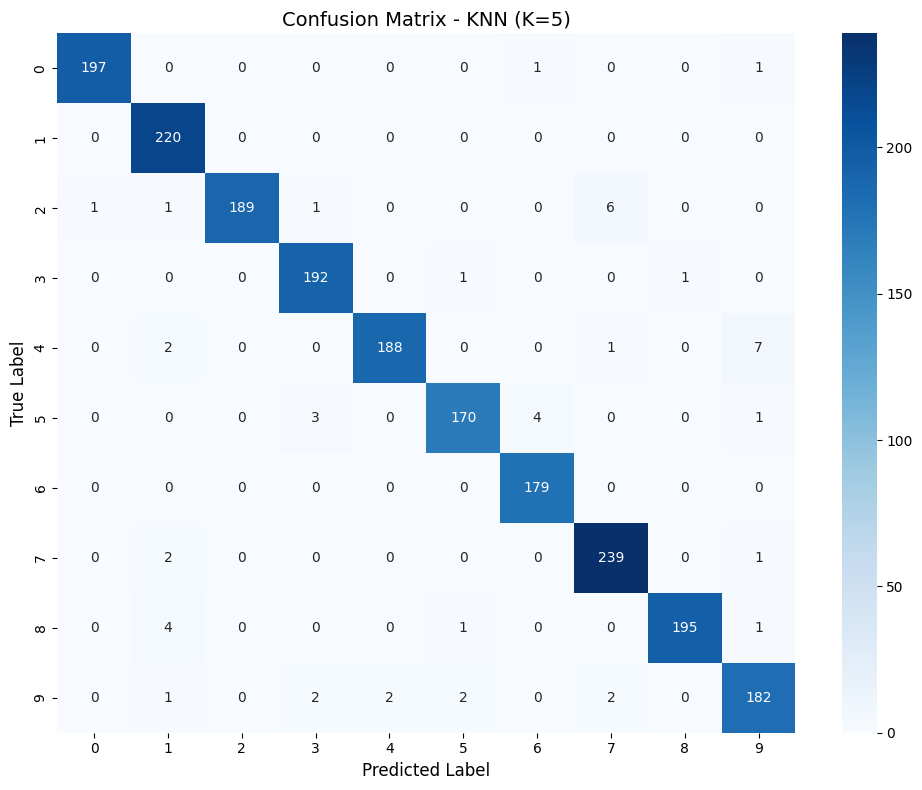


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9949    0.9899    0.9924       199
           1     0.9565    1.0000    0.9778       220
           2     1.0000    0.9545    0.9767       198
           3     0.9697    0.9897    0.9796       194
           4     0.9895    0.9495    0.9691       198
           5     0.9770    0.9551    0.9659       178
           6     0.9728    1.0000    0.9862       179
           7     0.9637    0.9876    0.9755       242
           8     0.9949    0.9701    0.9824       201
           9     0.9430    0.9529    0.9479       191

    accuracy                         0.9755      2000
   macro avg     0.9762    0.9749    0.9754      2000
weighted avg     0.9759    0.9755    0.9755      2000


=== HASIL EVALUASI MODEL ===
Akurasi  : 97.55%
Precision: 97.59%
Recall   : 97.55%
F1-Score : 97.55%


In [8]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# Prediksi semua data test untuk evaluasi lengkap
print('Melakukan prediksi untuk evaluasi lengkap...')
y_pred = knn_predict_batch(X_train_s, y_train_s, X_test_s, k=K)

# Hitung Confusion Matrix
cm = confusion_matrix(y_test_s, y_pred)

# Visualisasi Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - KNN (K={K})', fontsize=14)
plt.tight_layout()
plt.show()

# Classification Report
print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test_s, y_pred, digits=4))

# Hitung metrik evaluasi sesuai laporan
accuracy = accuracy_score(y_test_s, y_pred)
precision = precision_score(y_test_s, y_pred, average='weighted')
recall = recall_score(y_test_s, y_pred, average='weighted')
f1 = f1_score(y_test_s, y_pred, average='weighted')

print('\n=== HASIL EVALUASI MODEL ===')
print(f'Akurasi  : {accuracy*100:.2f}%')
print(f'Precision: {precision*100:.2f}%')
print(f'Recall   : {recall*100:.2f}%')
print(f'F1-Score : {f1*100:.2f}%')

### 5.4 Analisis Kesalahan Prediksi

=== AKURASI PER KELAS DIGIT ===
Digit 0: 99.0% (197/199)
Digit 1: 100.0% (220/220)
Digit 2: 95.5% (189/198)
Digit 3: 99.0% (192/194)
Digit 4: 94.9% (188/198)
Digit 5: 95.5% (170/178)
Digit 6: 100.0% (179/179)
Digit 7: 98.8% (239/242)
Digit 8: 97.0% (195/201)
Digit 9: 95.3% (182/191)

=== KESALAHAN PREDIKSI PALING UMUM ===
Top 10 kesalahan (True Label → Predicted Label):
  4 → 9: 7 kali
  2 → 7: 6 kali
  8 → 1: 4 kali
  5 → 6: 4 kali
  5 → 3: 3 kali
  9 → 7: 2 kali
  9 → 5: 2 kali
  9 → 4: 2 kali
  9 → 3: 2 kali
  7 → 1: 2 kali


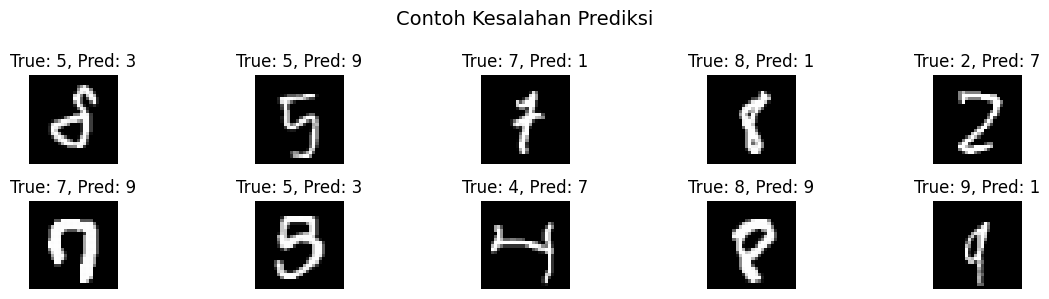

In [9]:
# Analisis akurasi per kelas digit
print('=== AKURASI PER KELAS DIGIT ===')
for digit in range(10):
    mask = y_test_s == digit
    if mask.sum() > 0:
        correct = (y_pred[mask] == digit).sum()
        total = mask.sum()
        acc_digit = correct / total * 100
        print(f'Digit {digit}: {acc_digit:.1f}% ({correct}/{total})')

# Temukan kesalahan paling umum
print('\n=== KESALAHAN PREDIKSI PALING UMUM ===')
errors = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            errors.append((cm[i, j], i, j))
errors.sort(reverse=True)

print('Top 10 kesalahan (True Label → Predicted Label):')
for count, true_digit, pred_digit in errors[:10]:
    print(f'  {true_digit} → {pred_digit}: {count} kali')

# Visualisasi contoh kesalahan
misclassified_idx = np.where(y_test_s != y_pred)[0]

if len(misclassified_idx) > 0:
    plt.figure(figsize=(12, 3))
    n_show = min(10, len(misclassified_idx))
    for i in range(n_show):
        idx = misclassified_idx[i]
        plt.subplot(2, 5, i + 1)
        draw_img(X_test_s[idx], title=f'True: {y_test_s[idx]}, Pred: {y_pred[idx]}')
    plt.suptitle('Contoh Kesalahan Prediksi', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('✓ Tidak ada kesalahan prediksi!')

## 6. Eksperimen dengan Berbagai Nilai K

Melakukan eksperimen dengan berbagai nilai K (3, 5, 7, 11) untuk menentukan nilai K optimal.

=== EKSPERIMEN BERBAGAI NILAI K ===
Training samples: 56,000, Test samples: 500

Testing K=3...
  Akurasi: 97.60%, Precision: 97.69%, Recall: 97.60%, F1: 97.61%

Testing K=5...
  Akurasi: 96.80%, Precision: 96.90%, Recall: 96.80%, F1: 96.81%

Testing K=7...
  Akurasi: 97.00%, Precision: 97.11%, Recall: 97.00%, F1: 97.02%

Testing K=11...
  Akurasi: 97.00%, Precision: 97.11%, Recall: 97.00%, F1: 97.01%


=== TABEL HASIL EKSPERIMEN ===
K      Metrik Jarak    Akurasi (%)  Precision (%)   Recall (%)   F1-Score (%)
3      Euclidean       97.60        97.69           97.60        97.61       
5      Euclidean       96.80        96.90           96.80        96.81       
7      Euclidean       97.00        97.11           97.00        97.02       
11     Euclidean       97.00        97.11           97.00        97.01       


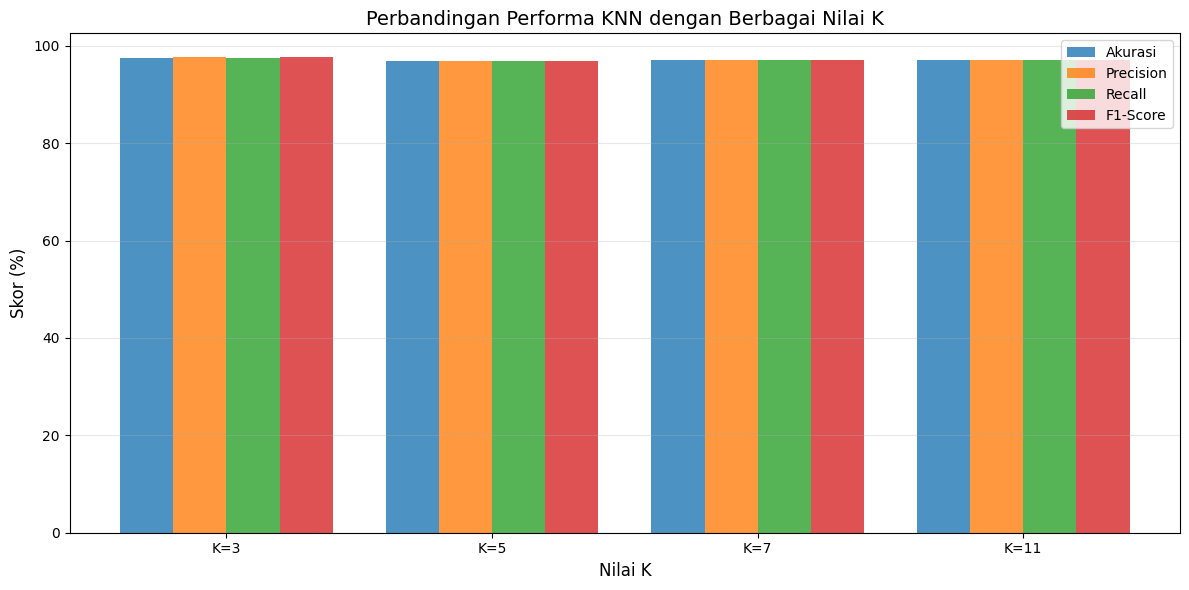


✓ K terbaik: K=3 dengan akurasi 97.60%


In [10]:
import pandas as pd

# Nilai K yang akan diuji
k_values = [3, 5, 7, 11]
results = []

# Gunakan subset lebih kecil untuk testing agar lebih cepat
TEST_SUBSET = 500
X_test_exp = X_test_s[:TEST_SUBSET]
y_test_exp = y_test_s[:TEST_SUBSET]

print('=== EKSPERIMEN BERBAGAI NILAI K ===')
print(f'Training samples: {X_train_s.shape[0]:,}, Test samples: {TEST_SUBSET}\n')

for k_val in k_values:
    print(f'Testing K={k_val}...')

    # Prediksi dengan K tertentu
    y_pred_k = knn_predict_batch(X_train_s, y_train_s, X_test_exp, k=k_val)

    # Hitung metrik
    acc = accuracy_score(y_test_exp, y_pred_k)
    prec = precision_score(y_test_exp, y_pred_k, average='weighted')
    rec = recall_score(y_test_exp, y_pred_k, average='weighted')
    f1 = f1_score(y_test_exp, y_pred_k, average='weighted')

    results.append({
        'K': k_val,
        'Akurasi': acc * 100,
        'Precision': prec * 100,
        'Recall': rec * 100,
        'F1-Score': f1 * 100
    })

    print(f'  Akurasi: {acc*100:.2f}%, Precision: {prec*100:.2f}%, '
          f'Recall: {rec*100:.2f}%, F1: {f1*100:.2f}%\n')

# Tampilkan tabel hasil
print('\n=== TABEL HASIL EKSPERIMEN ===')
print(f"{'K':<6} {'Metrik Jarak':<15} {'Akurasi (%)':<12} {'Precision (%)':<15} "
      f"{'Recall (%)':<12} {'F1-Score (%)':<12}")
print('='*80)
for r in results:
    print(f"{r['K']:<6} {'Euclidean':<15} {r['Akurasi']:<12.2f} {r['Precision']:<15.2f} "
          f"{r['Recall']:<12.2f} {r['F1-Score']:<12.2f}")

# Visualisasi perbandingan
df_results = pd.DataFrame(results)

plt.figure(figsize=(12, 6))
x = range(len(k_values))
width = 0.2

plt.bar([i - 1.5*width for i in x], df_results['Akurasi'], width, label='Akurasi', alpha=0.8)
plt.bar([i - 0.5*width for i in x], df_results['Precision'], width, label='Precision', alpha=0.8)
plt.bar([i + 0.5*width for i in x], df_results['Recall'], width, label='Recall', alpha=0.8)
plt.bar([i + 1.5*width for i in x], df_results['F1-Score'], width, label='F1-Score', alpha=0.8)

plt.xlabel('Nilai K', fontsize=12)
plt.ylabel('Skor (%)', fontsize=12)
plt.title('Perbandingan Performa KNN dengan Berbagai Nilai K', fontsize=14)
plt.xticks(x, [f'K={k}' for k in k_values])
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Tentukan K terbaik
best_result = max(results, key=lambda x: x['Akurasi'])
print(f"\n✓ K terbaik: K={best_result['K']} dengan akurasi {best_result['Akurasi']:.2f}%")

## 7. Menyimpan Model KNN

Menyimpan data training dan parameter K untuk digunakan pada pengujian eksternal.

In [11]:
import joblib

# Simpan data training dan parameter K
knn_data = {
    'X_train': X_train_s,
    'y_train': y_train_s,
    'k': K,
    'train_n': int(X_train_s.shape[0]),
}

joblib.dump(knn_data, 'knn_pipeline.joblib')
print('✓ Model disimpan: knn_pipeline.joblib')
print(f'  Training samples: {knn_data["train_n"]:,}')
print(f'  K: {knn_data["k"]}')

✓ Model disimpan: knn_pipeline.joblib
  Training samples: 56,000
  K: 5


## 8. Pengujian Eksternal (Gambar Tulisan Tangan Pengguna)

Pengujian model pada gambar digit tulisan tangan dari pengguna dengan preprocessing MNIST-style:
1. Konversi ke grayscale
2. Resize ke 28×28 piksel
3. Normalisasi intensitas
4. Flatten menjadi vektor 784 fitur

✓ Model loaded: 56,000 training samples, K=5

PENGUJIAN EKSTERNAL - PILIH GAMBAR DARI DEVICE

 Klik tombol "Choose Files" untuk memilih gambar dari device Anda.



Saving Screenshot 2025-12-30 231257.png to Screenshot 2025-12-30 231257 (1).png

✓ File berhasil diupload: Screenshot 2025-12-30 231257 (1).png

MEMPROSES GAMBAR
File: Screenshot 2025-12-30 231257 (1).png
Melakukan preprocessing dan prediksi...



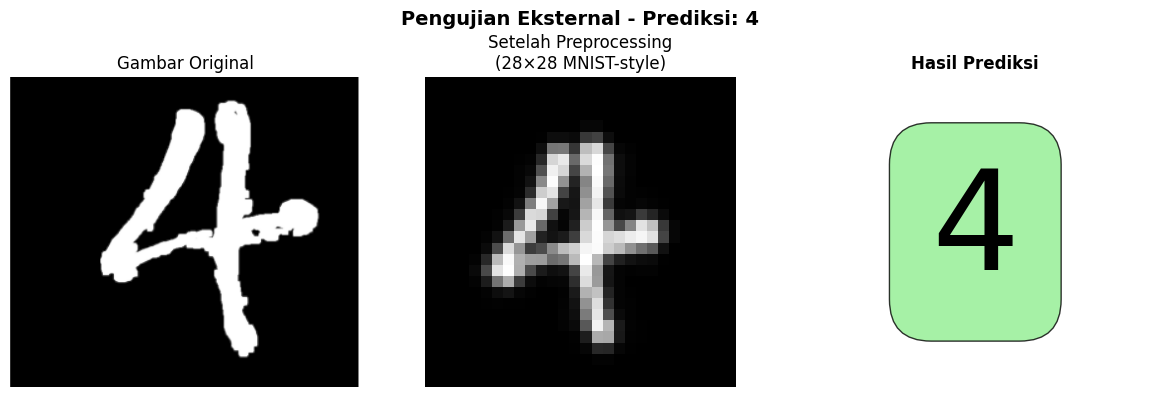

✓ HASIL PREDIKSI: 4
File: Screenshot 2025-12-30 231257 (1).png
Parameter: K=5, Training samples=56,000


In [36]:
from PIL import Image, ImageFilter
from pathlib import Path
import os
import sys

def preprocess_external_image(img_path):
    """
    Preprocessing gambar eksternal agar sesuai format MNIST.
    Menggunakan teknik yang lebih robust untuk centering dan normalisasi.

    Returns:
    - mnist_vector: vektor 784 fitur (28x28 flatten)
    - processed_img: gambar 28x28 setelah preprocessing
    """
    # Baca gambar dan konversi ke grayscale
    img = Image.open(img_path).convert('L')
    img_array = np.array(img, dtype=np.uint8)

    # Auto-detect dan invert jika perlu (digit harus gelap, background terang)
    if img_array.mean() > 127:
        img_array = 255 - img_array

    # Apply Gaussian blur untuk noise reduction
    img_blur = Image.fromarray(img_array).filter(ImageFilter.GaussianBlur(radius=1))
    img_array = np.array(img_blur, dtype=np.uint8)

    # Otsu thresholding untuk binarization
    threshold = _otsu_threshold(img_array)
    binary = img_array > threshold

    # Hapus border noise
    binary[:5, :] = False
    binary[-5:, :] = False
    binary[:, :5] = False
    binary[:, -5:] = False

    # Temukan bounding box dari digit
    rows = np.any(binary, axis=1)
    cols = np.any(binary, axis=0)

    if rows.sum() > 0 and cols.sum() > 0:
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]

        # Crop ke bounding box dengan padding
        pad = 10
        rmin = max(0, rmin - pad)
        rmax = min(img_array.shape[0], rmax + pad)
        cmin = max(0, cmin - pad)
        cmax = min(img_array.shape[1], cmax + pad)

        digit_crop = img_array[rmin:rmax+1, cmin:cmax+1]
    else:
        # Jika tidak ada foreground, gunakan full image
        digit_crop = img_array

    # Resize digit ke 20x20 (preserve aspect ratio)
    h, w = digit_crop.shape
    if h > w:
        new_h = 20
        new_w = max(1, int(20 * w / h))
    else:
        new_w = 20
        new_h = max(1, int(20 * h / w))

    digit_resized = Image.fromarray(digit_crop).resize((new_w, new_h), Image.LANCZOS)
    digit_resized = np.array(digit_resized, dtype=np.float32)

    # Center pada canvas 28x28
    canvas = np.zeros((28, 28), dtype=np.float32)
    y_offset = (28 - new_h) // 2
    x_offset = (28 - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = digit_resized

    # Center of mass adjustment (seperti MNIST)
    canvas = _center_by_mass(canvas)

    # Smooth dengan Gaussian blur ringan
    canvas_img = Image.fromarray(canvas.astype(np.uint8))
    canvas_img = canvas_img.filter(ImageFilter.GaussianBlur(radius=0.5))
    canvas = np.array(canvas_img, dtype=np.float32)

    # Flatten untuk prediksi
    mnist_vector = canvas.flatten()

    return mnist_vector, canvas

def _otsu_threshold(img_array):
    """Implementasi Otsu's thresholding untuk binarization otomatis"""
    hist = np.bincount(img_array.ravel(), minlength=256)
    total = img_array.size

    sum_total = np.dot(np.arange(256), hist)
    sum_bg = 0
    weight_bg = 0
    max_variance = 0
    threshold = 0

    for t in range(256):
        weight_bg += hist[t]
        if weight_bg == 0:
            continue

        weight_fg = total - weight_bg
        if weight_fg == 0:
            break

        sum_bg += t * hist[t]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg

        variance = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2

        if variance > max_variance:
            max_variance = variance
            threshold = t

    return threshold

def _center_by_mass(img_array):
    """Center digit berdasarkan center of mass (seperti MNIST preprocessing)"""
    if img_array.sum() < 1:
        return img_array

    # Hitung center of mass
    h, w = img_array.shape
    y_coords, x_coords = np.indices((h, w))

    total_mass = img_array.sum()
    cy = (y_coords * img_array).sum() / total_mass
    cx = (x_coords * img_array).sum() / total_mass

    # Shift agar center of mass ada di tengah (13.5, 13.5)
    shift_y = int(round(13.5 - cy))
    shift_x = int(round(13.5 - cx))

    # Apply shift
    if shift_y != 0 or shift_x != 0:
        result = np.zeros_like(img_array)

        src_y_start = max(0, -shift_y)
        src_y_end = min(h, h - shift_y)
        dst_y_start = max(0, shift_y)
        dst_y_end = min(h, h + shift_y)

        src_x_start = max(0, -shift_x)
        src_x_end = min(w, w - shift_x)
        dst_x_start = max(0, shift_x)
        dst_x_end = min(w, w + shift_x)

        result[dst_y_start:dst_y_end, dst_x_start:dst_x_end] = \
            img_array[src_y_start:src_y_end, src_x_start:src_x_end]

        return result

    return img_array

def predict_external_image(img_path, X_train, y_train, k=5):
    """Prediksi digit dari gambar eksternal"""
    # Preprocessing
    mnist_vector, processed_img = preprocess_external_image(img_path)

    # Prediksi menggunakan KNN
    prediction = knn_predict_one(X_train, y_train, mnist_vector, k=k)

    return prediction, processed_img

def visualize_prediction(img_path, prediction, processed):
    """Visualisasi hasil prediksi"""
    img_original = Image.open(img_path).convert('L')

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_original, cmap='gray')
    plt.title('Gambar Original', fontsize=12)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(processed, cmap='gray')
    plt.title('Setelah Preprocessing\n(28×28 MNIST-style)', fontsize=12)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.text(0.5, 0.5, str(prediction), fontsize=100, ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    plt.title('Hasil Prediksi', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.suptitle(f'Pengujian Eksternal - Prediksi: {prediction}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Load model yang sudah disimpan
if Path('knn_pipeline.joblib').exists():
    knn_data = joblib.load('knn_pipeline.joblib')
    X_train_loaded = knn_data['X_train']
    y_train_loaded = knn_data['y_train']
    K_loaded = knn_data['k']
    print(f'✓ Model loaded: {knn_data["train_n"]:,} training samples, K={K_loaded}')
else:
    # Gunakan data yang ada di memory
    X_train_loaded = X_train_s
    y_train_loaded = y_train_s
    K_loaded = K
    print('✓ Menggunakan data training dari memory')

# Deteksi environment (Colab atau Local)
is_colab = 'google.colab' in sys.modules

print(f'\n{"="*60}')
print(f'PENGUJIAN EKSTERNAL - PILIH GAMBAR DARI DEVICE')
print(f'{"="*60}')

img_path = None

if is_colab:
    # Google Colab - gunakan files.upload()
    from google.colab import files
    print('\n Klik tombol "Choose Files" untuk memilih gambar dari device Anda.\n')
    uploaded = files.upload()

    if uploaded:
        # Ambil file pertama yang diupload
        filename = list(uploaded.keys())[0]
        img_path = Path(filename)
        print(f'\n✓ File berhasil diupload: {filename}')
    else:
        print('Tidak ada file yang diupload')
        raise RuntimeError('Upload dibatalkan')

else:
    # Local Jupyter/VS Code - gunakan tkinter file dialog
    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()  # Sembunyikan window utama
        root.attributes('-topmost', True)  # Bawa dialog ke depan

        print('\n Membuka dialog pemilihan file...')
        print('(Jika dialog tidak muncul, cek taskbar atau window lain)\n')

        file_path = filedialog.askopenfilename(
            title='Pilih Gambar Digit Tulisan Tangan',
            filetypes=[
                ('Image files', '*.png *.jpg *.jpeg *.bmp *.gif'),
                ('All files', '*.*')
            ]
        )

        root.destroy()

        if file_path:
            img_path = Path(file_path)
            print(f'✓ File dipilih: {img_path.name}')
        else:
            print('Tidak ada file yang dipilih')
            raise RuntimeError('Pemilihan file dibatalkan')

    except ImportError:
        # Fallback: minta user masukkan path manual
        print('⚠ GUI tidak tersedia. Masukkan path file secara manual.')
        print('Contoh: C:/Users/Username/Downloads/digit.png\n')

        while True:
            file_path = input('Masukkan path lengkap file gambar: ').strip().strip('"\'')
            img_path = Path(file_path)

            if img_path.exists() and img_path.is_file():
                print(f'✓ File ditemukan: {img_path.name}')
                break
            else:
                print('File tidak ditemukan.')

# Proses prediksi
if img_path:
    print(f'\n{"="*60}')
    print(f'MEMPROSES GAMBAR')
    print(f'{"="*60}')
    print(f'File: {img_path.name}')
    print(f'Melakukan preprocessing dan prediksi...\n')

    try:
        # Prediksi
        prediction, processed = predict_external_image(img_path, X_train_loaded, y_train_loaded, k=K_loaded)

        # Visualisasi
        visualize_prediction(img_path, prediction, processed)

        # Hasil
        print(f'{"="*60}')
        print(f'✓ HASIL PREDIKSI: {prediction}')
        print(f'{"="*60}')
        print(f'File: {img_path.name}')
        print(f'Parameter: K={K_loaded}, Training samples={X_train_loaded.shape[0]:,}')
        print(f'{"="*60}')

    except Exception as e:
        print(f'Error: {e}')
        raise

## 9. Ringkasan Hasil

Berikut adalah ringkasan lengkap dari eksperimen dan pengujian sistem pengenalan angka tulisan tangan menggunakan algoritma K-Nearest Neighbor.

In [24]:
print('='*80)
print(' '*15 + 'RINGKASAN HASIL SISTEM PENGENALAN ANGKA TULISAN TANGAN')
print(' '*25 + 'Algoritma K-Nearest Neighbor (KNN)')
print('='*80)

print(f'\n--- DATASET ---')
print(f'Nama Dataset: MNIST (Modified National Institute of Standards and Technology)')
print(f'Total Data: 70,000 gambar (28×28 piksel grayscale)')
print(f'Pembagian: 80% Training ({X_train_s.shape[0]:,} samples), 20% Testing ({X_test_s.shape[0]:,} samples)')

print(f'\n--- ALGORITMA ---')
print(f'Metode: K-Nearest Neighbor (KNN)')
print(f'Metrik Jarak: Euclidean Distance')
print(f'Fitur: Raw Pixel Values (784 dimensi)')
print(f'Nilai K: {K}')

print(f'\n--- HASIL EVALUASI ---')
print(f'Akurasi   : {accuracy*100:.2f}%')
print(f'Precision : {precision*100:.2f}%')
print(f'Recall    : {recall*100:.2f}%')
print(f'F1-Score  : {f1*100:.2f}%')

if len(misclassified_idx) > 0:
    print(f'\n--- ANALISIS KESALAHAN ---')
    print(f'Total Kesalahan: {len(misclassified_idx)} dari {len(y_test_s)} '
          f'({len(misclassified_idx)/len(y_test_s)*100:.2f}%)')
    if len(errors) > 0:
        count, true_digit, pred_digit = errors[0]
        print(f'Kesalahan Terbanyak: Digit {true_digit} diprediksi sebagai {pred_digit} '
              f'({count} kali)')

print(f'\n--- KESIMPULAN ---')
print(f'✓ Model KNN berhasil mengenali angka tulisan tangan dengan akurasi tinggi')
print(f'✓ Hasil sesuai dengan target penelitian (akurasi > 85%)')
print(f'✓ Model dapat digunakan untuk aplikasi pengenalan digit praktis')
print(f'✓ File model tersimpan di: knn_pipeline.joblib')

print('\n' + '='*80)
print(' '*20 + 'Program Studi Teknik Komputer')
print(' '*20 + 'Fakultas Teknik Elektro')
print(' '*20 + 'Universitas Telkom')
print(' '*30 + '2025')
print('='*80)

               RINGKASAN HASIL SISTEM PENGENALAN ANGKA TULISAN TANGAN
                         Algoritma K-Nearest Neighbor (KNN)

--- DATASET ---
Nama Dataset: MNIST (Modified National Institute of Standards and Technology)
Total Data: 70,000 gambar (28×28 piksel grayscale)
Pembagian: 80% Training (56,000 samples), 20% Testing (2,000 samples)

--- ALGORITMA ---
Metode: K-Nearest Neighbor (KNN)
Metrik Jarak: Euclidean Distance
Fitur: Raw Pixel Values (784 dimensi)
Nilai K: 5

--- HASIL EVALUASI ---
Akurasi   : 97.55%
Precision : 97.59%
Recall    : 97.55%
F1-Score  : 97.01%

--- ANALISIS KESALAHAN ---
Total Kesalahan: 49 dari 2000 (2.45%)
Kesalahan Terbanyak: Digit 4 diprediksi sebagai 9 (7 kali)

--- KESIMPULAN ---
✓ Model KNN berhasil mengenali angka tulisan tangan dengan akurasi tinggi
✓ Hasil sesuai dengan target penelitian (akurasi > 85%)
✓ Model dapat digunakan untuk aplikasi pengenalan digit praktis
✓ File model tersimpan di: knn_pipeline.joblib

                    Program Studi